In [2]:
from pathlib import Path

path = Path("/Users/carlasequero/Desktop/trabajo-fin-master/solution/data/06_training_data/training_03.h5")

print(path.exists())
print(path.stat().st_size / 1024**2, "MB")

True
925.6194267272949 MB


In [3]:
import h5py

path = "/Users/carlasequero/Desktop/trabajo-fin-master/solution/data/06_training_data/training_03.h5"

with h5py.File(path, "r") as f:
    print(list(f.keys()))

['X', 'X_err', 'gaia_source_id', 'gaia_wavelength_nm', 'sdss_obj_id', 'sdss_wavelength_aa', 'y']


In [4]:
with h5py.File(path, "r") as f:
    print("X:", f["X"].shape)
    print("X_err:", f["X_err"].shape)
    print("y:", f["y"].shape)
    print("gaia wavelengths:", f["gaia_wavelength_nm"].shape)
    print("sdss wavelengths:", f["sdss_wavelength_aa"].shape)

X: (55621, 343)
X_err: (55621, 343)
y: (55621, 3600)
gaia wavelengths: (343,)
sdss wavelengths: (3600,)


In [5]:
import numpy as np

with h5py.File(path, "r") as f:
    X = f["X"][:]
    X_err = f["X_err"][:]
    y = f["y"][:]

    gaia_wavelength = f["gaia_wavelength_nm"][:]
    sdss_wavelength = f["sdss_wavelength_aa"][:]

print(X.shape)
print(y.shape)

(55621, 343)
(55621, 3600)


In [6]:
# Nos quedamos solo con el intervalo común de ambos datos 
gaia_mask = (gaia_wavelength >= 500) & (gaia_wavelength <= 900)
sdss_mask = (sdss_wavelength >= 5000) & (sdss_wavelength <= 9000)

X = X[:, gaia_mask]
X_err = X_err[:, gaia_mask]
y = y[:, sdss_mask]

gaia_wavelength = gaia_wavelength[gaia_mask]
sdss_wavelength = sdss_wavelength[sdss_mask]

print(X.shape)
print(y.shape)

(55621, 201)
(55621, 2666)


In [7]:
gaia_flux_like_sdss = X / 1e-19

# Calculamos la escala de los espectros
gaia_scale = np.nanmedian(np.abs(gaia_flux_like_sdss), axis=1)
sdss_scale = np.nanmedian(np.abs(y), axis=1)

# Ratio Gaia / SDSS
scale_ratio = gaia_scale / (sdss_scale)

print(np.nanpercentile(scale_ratio, [0, 1, 2, 5, 10, 50, 90, 95, 98, 99, 100]))

[0.0256451  0.63751963 0.67069547 0.72489202 0.80475909 0.97298855
 1.25146067 1.40597987 1.54379449 1.82763968        nan]


/var/folders/39/1wfqcmsn0g5drvtznv_yzdhw0000gn/T/ipykernel_26651/415622475.py:8: RuntimeWarning: divide by zero encountered in divide
  scale_ratio = gaia_scale / (sdss_scale)
/opt/anaconda3/lib/python3.12/site-packages/numpy/lib/function_base.py:4655: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


In [8]:
import numpy as np

X_model = X
y_model = y

finite_mask = (
    np.isfinite(X_model).all(axis=1)
    & np.isfinite(y_model).all(axis=1)
)

y_p1 = np.nanpercentile(y_model, 1, axis=1)
y_p99 = np.nanpercentile(y_model, 99, axis=1)
y_p5 = np.nanpercentile(y_model, 5, axis=1)
y_p95 = np.nanpercentile(y_model, 95, axis=1)
y_median = np.nanmedian(np.abs(y_model), axis=1) + 1e-8
y_difference5 = y_p95 - y_p5

dynamic_range = y_p99 - y_p1
relative_range = dynamic_range / y_median

In [9]:
print(np.nanpercentile(y_median, [0, 1, 2, 5, 10, 50, 90, 95, 98, 99, 100]))

print(np.nanpercentile(y_difference5, [0, 1, 2, 5, 10, 50, 90, 95, 98, 99, 100]))

[9.99999994e-09 2.32202191e+00 4.20667629e+00 5.72647810e+00
 7.30792427e+00 4.13982620e+01 1.29891296e+02 1.64941925e+02
 2.01740402e+02 2.37652231e+02 5.67021191e+03]
[   0.            4.24971336    4.83444867    6.0330925     7.65894794
   27.92912245   92.13323593  127.33889771  183.89729919  229.7072649
 2249.87664795]


In [10]:
valid = (
    finite_mask
    & (dynamic_range < np.percentile(dynamic_range, 99))
    & (relative_range < np.percentile(relative_range, 99))
    & (y_median < np.nanpercentile(y_median, 99))
    & (y_median > np.nanpercentile(y_median, 1))
    & (y_difference5 < np.nanpercentile(y_difference5, 99))
    & (y_difference5 > np.nanpercentile(y_difference5, 1))
    & (scale_ratio < np.nanpercentile(scale_ratio, 95))
    & (scale_ratio > np.nanpercentile(scale_ratio, 5))
)

print("Antes:", X_model.shape[0])
print("Después:", valid.sum())

X_model = X_model[valid]
y_model = y_model[valid]

Antes: 55621
Después: 48776


In [40]:

def group_bines(wavelength, flux, factor = 4):
    n_points_original = flux.shape[1]

    # Definimos la cantidad de puntos a usar como un múltiple del factor (número de bines a agrupar)
    n_points_group = (n_points_original // factor) * factor

    wavelength = wavelength[:n_points_group]
    flux = flux[:, : n_points_group]
    
    grouped_wavelength = wavelength.reshape(-1, factor).mean(axis=1)
    grouped_flux = flux.reshape(flux.shape[0], -1, factor).mean(axis=2)

    return grouped_wavelength, grouped_flux


sdss_wavelength_binned, y_binned = group_bines(
    sdss_wavelength,
    y_model,
    factor=7
)
y_model = y_binned

In [11]:
print(y_model.shape)

(48776, 2666)


In [12]:
from sklearn.model_selection import train_test_split

# Separamos en train y temp, luego el temp lo usaremos para separar en test y validation para que los espectros queden mezclados

X_temp, X_test, y_temp, y_test = train_test_split(
    X_model,
    y_model,
    test_size=0.2,
    random_state=23,
    shuffle=True
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.2,
    random_state=23,
    shuffle=True
)

# Normalizamos los datos
X_mean = X_train.mean()
X_std = X_train.std()

y_mean = y_train.mean()
y_std = y_train.std()

X_train_norm = (X_train - X_mean) / X_std
X_val_norm = (X_val - X_mean) / X_std
X_test_norm = (X_test - X_mean) / X_std

y_train_norm = (y_train - y_mean) / y_std
y_val_norm = (y_val - y_mean) / y_std
y_test_norm = (y_test - y_mean) / y_std

In [13]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

n_gaia = X_train.shape[1]
n_sdss = y_train.shape[1]

model = models.Sequential([
    layers.Input(shape=(n_gaia,)),

    layers.Dense(512),#, activation="elu"),#relu
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(1024, activation="elu"),
    
    layers.Dense(1024),
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(1024, activation="elu"),

    layers.Dense(n_sdss)
])

model.compile(
    optimizer=Adam(learning_rate=1e-4, clipnorm = 1.0),
    loss= tf.keras.losses.Huber(delta=1.0),
    metrics=["mae", "mse"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       103,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 2666)           │     2,732,650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,460,586 (20.83 MB)

 Trainable params: 5,460,586 (20.83 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5, # 4 EN SU OPTIMO ESTADO, 
    min_delta = 1e-4,
    restore_best_weights=True
)

from tensorflow.keras.callbacks import ReduceLROnPlateau
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    X_train_norm,
    y_train_norm,
    validation_data=(X_val_norm, y_val_norm),
    epochs=50,
    batch_size=64, #32 PARA QUE VAYA EN SU OPTIMO ESTADO
    callbacks=[early_stop,reduce_lr],
    verbose=1
)


Epoch 1/50
488/488 ━━━━━━━━━━━━━━━━━━━━ 25s 48ms/step - loss: 0.0666 - mae: 0.2118 - mse: 0.1597 - val_loss: 0.0121 - val_mae: 0.0909 - val_mse: 0.0251 - learning_rate: 1.0000e-04
Epoch 2/50
488/488 ━━━━━━━━━━━━━━━━━━━━ 25s 50ms/step - loss: 0.0126 - mae: 0.0903 - mse: 0.0274 - val_loss: 0.0117 - val_mae: 0.0869 - val_mse: 0.0242 - learning_rate: 1.0000e-04
Epoch 3/50
488/488 ━━━━━━━━━━━━━━━━━━━━ 23s 48ms/step - loss: 0.0123 - mae: 0.0891 - mse: 0.0270 - val_loss: 0.0114 - val_mae: 0.0886 - val_mse: 0.0236 - learning_rate: 1.0000e-04
Epoch 4/50
488/488 ━━━━━━━━━━━━━━━━━━━━ 41s 84ms/step - loss: 0.0112 - mae: 0.0857 - mse: 0.0244 - val_loss: 0.0114 - val_mae: 0.0897 - val_mse: 0.0237 - learning_rate: 1.0000e-04
Epoch 5/50
487/488 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.0109 - mae: 0.0851 - mse: 0.0236
Epoch 5: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
488/488 ━━━━━━━━━━━━━━━━━━━━ 33s 67ms/step - loss: 0.0109 - mae: 0.0851 - mse: 0.0236 - val_loss: 0.0116 - v

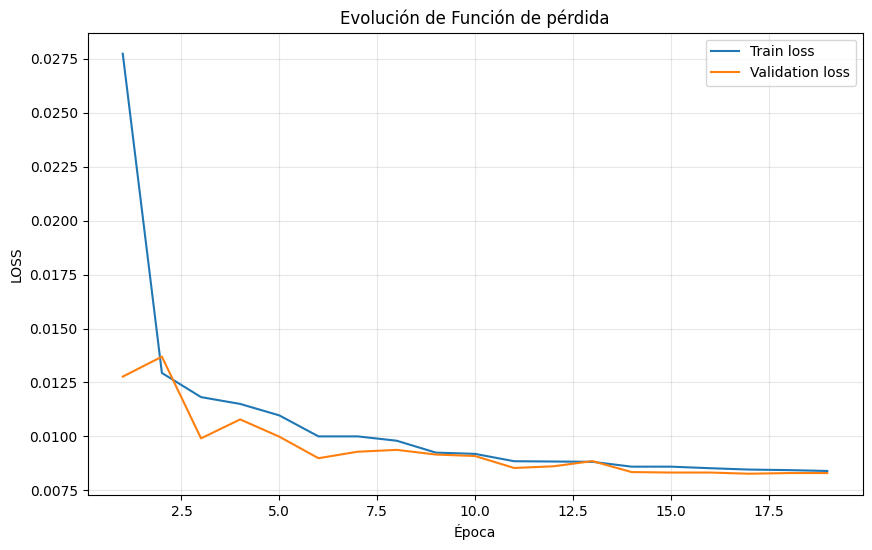

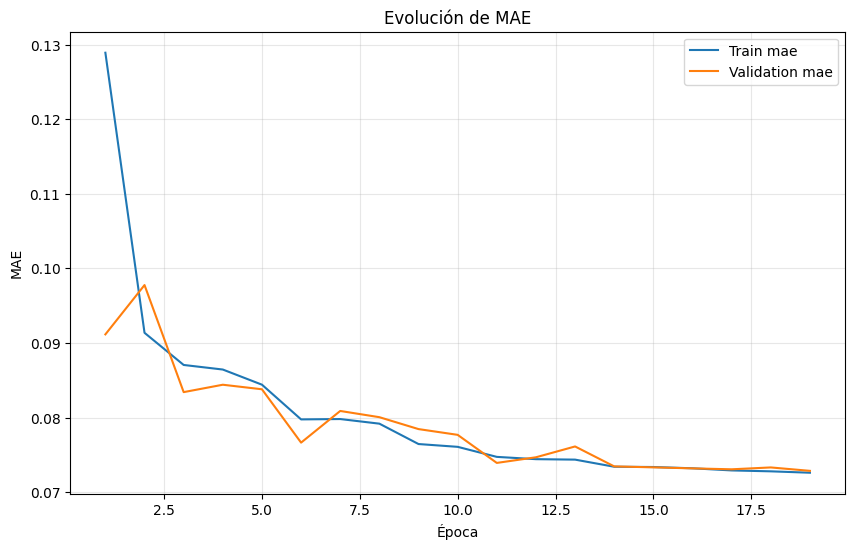

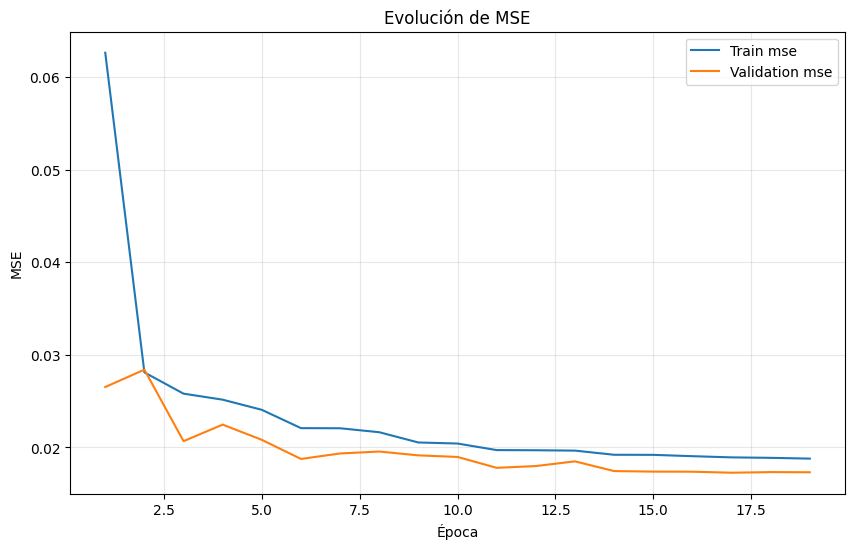

In [16]:
import matplotlib.pyplot as plt

history_dict = history.history
epochs = range(1, len(history_dict["loss"]) + 1)

metrics = [
    ("loss", "Función de pérdida"),
    ("mae", "MAE"),
    ("mse", "MSE")
]

for metric, title in metrics:
    plt.figure(figsize=(10, 6))

    plt.plot(epochs, history_dict[metric], label=f"Train {metric}")
    plt.plot(epochs, history_dict[f"val_{metric}"], label=f"Validation {metric}")

    plt.xlabel("Época")
    plt.ylabel(metric.upper())
    plt.title(f"Evolución de {title}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

In [15]:
y_pred_norm = model.predict(X_test_norm)
y_pred = y_pred_norm * y_std + y_mean

305/305 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


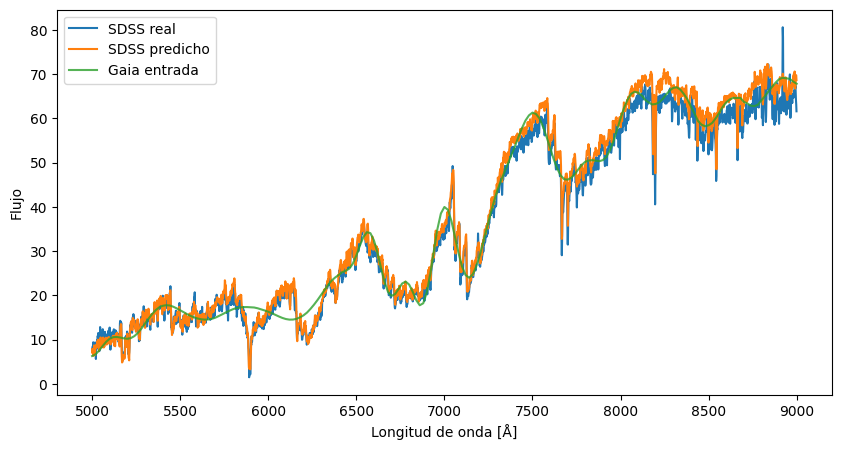

In [16]:
import matplotlib.pyplot as plt

i = 123
#, 23, 178
gaia_wavelength_ams = gaia_wavelength * 10
gaia_in_sdss_units = X_test[i] / 1e-19

plt.figure(figsize=(10, 5))
plt.plot(sdss_wavelength, y_test[i], label="SDSS real")
plt.plot(sdss_wavelength, y_pred[i], label="SDSS predicho")
plt.plot(gaia_wavelength_ams, gaia_in_sdss_units, label="Gaia entrada", alpha=0.8)
plt.xlabel("Longitud de onda [Å]")
plt.ylabel("Flujo")
plt.legend()
plt.show()

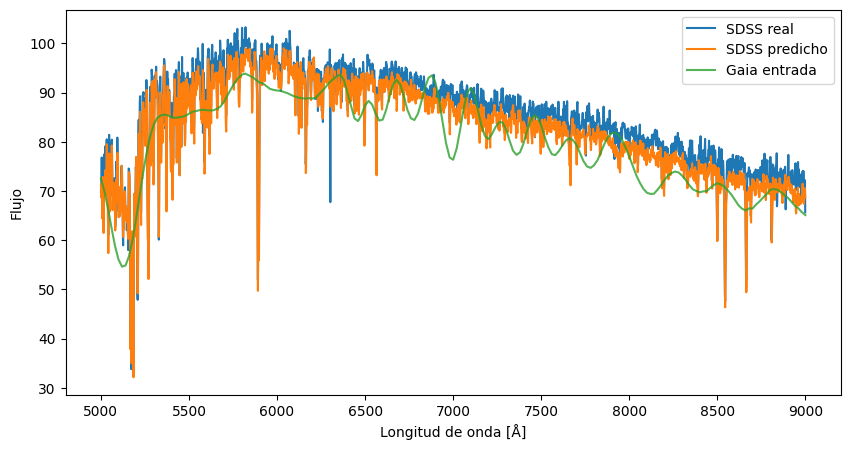

In [17]:

i = 191
#, 23, 178
gaia_wavelength_ams = gaia_wavelength * 10
gaia_in_sdss_units = X_test[i] / 1e-19

plt.figure(figsize=(10, 5))
plt.plot(sdss_wavelength, y_test[i], label="SDSS real")
plt.plot(sdss_wavelength, y_pred[i], label="SDSS predicho")
plt.plot(gaia_wavelength_ams, gaia_in_sdss_units, label="Gaia entrada", alpha=0.8)
plt.xlabel("Longitud de onda [Å]")
plt.ylabel("Flujo")
plt.legend()
plt.show()

In [18]:
test_loss, test_mae, test_mse = model.evaluate(
    X_test_norm,
    y_test_norm,
    verbose=1
)

305/305 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0087 - mae: 0.0734 - mse: 0.0187


In [47]:
test_loss, test_mae, test_mse = model.evaluate(
    X_test_norm,
    y_test_norm,
    verbose=1
)

305/305 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0081 - mae: 0.0697 - mse: 0.0168


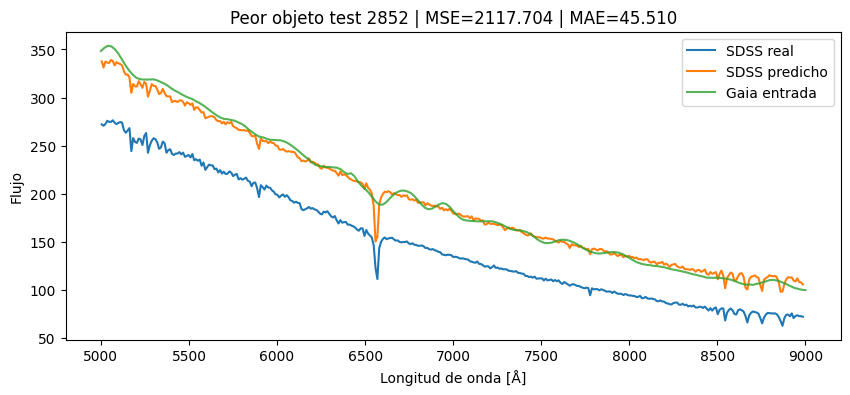

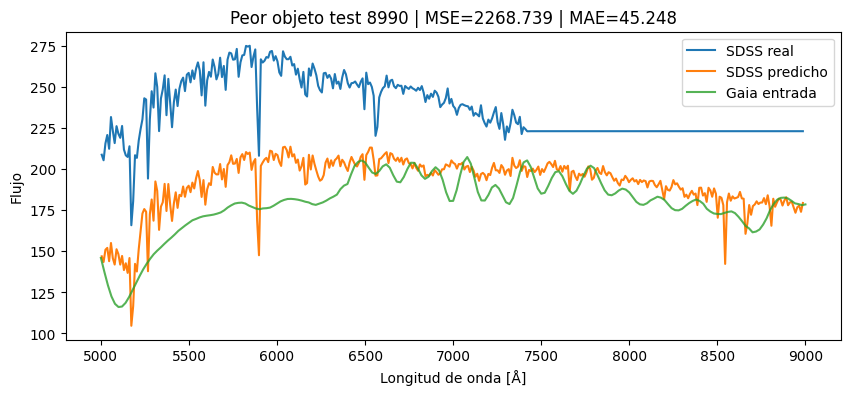

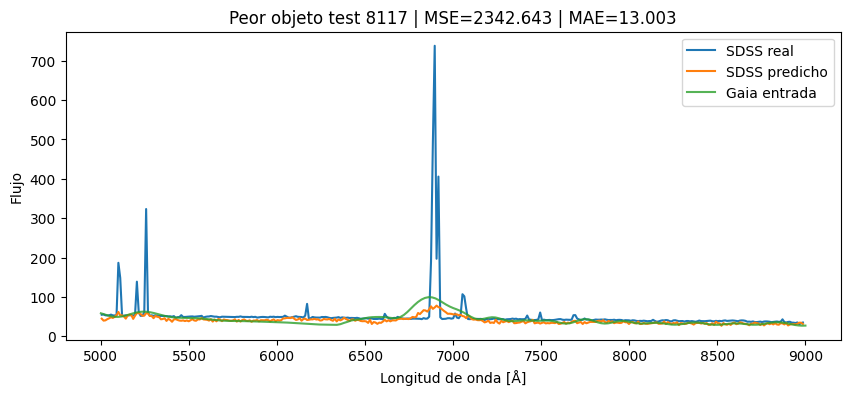

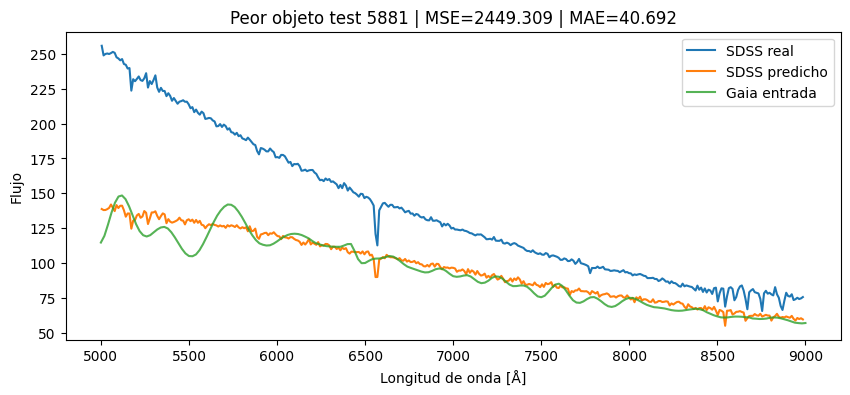

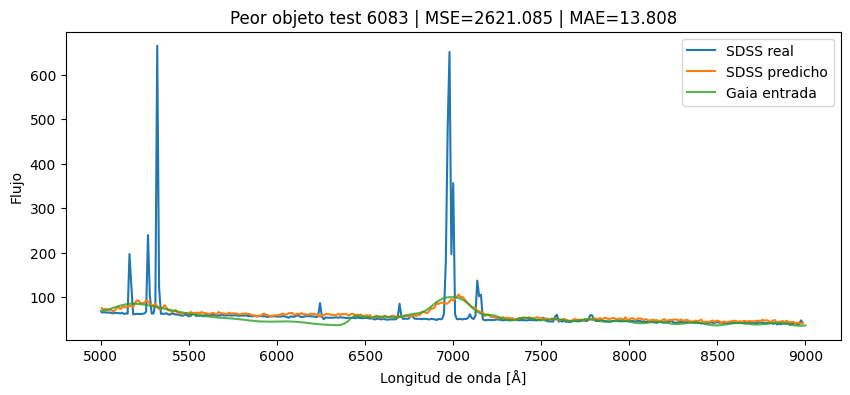

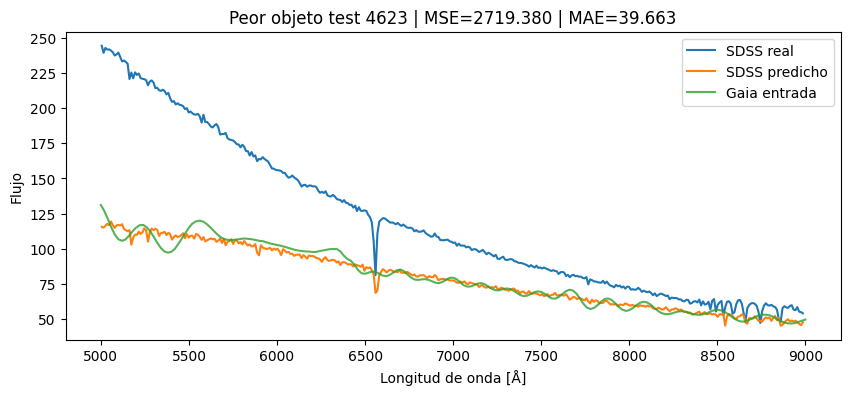

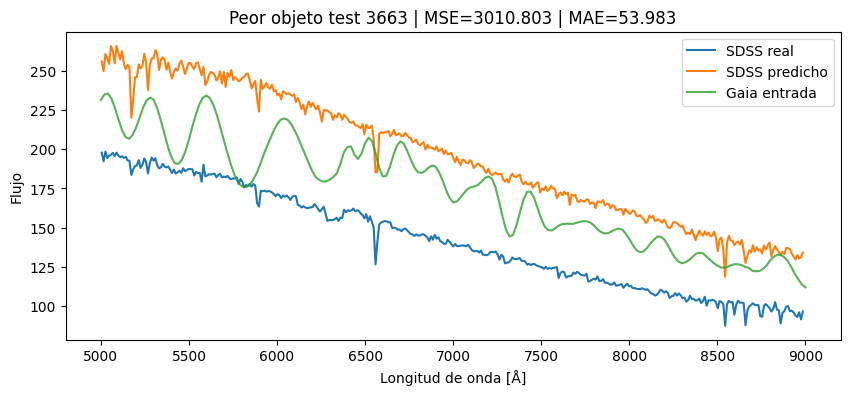

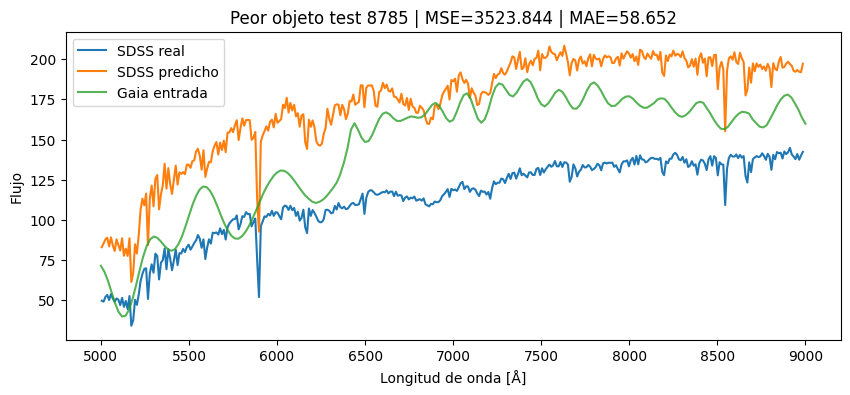

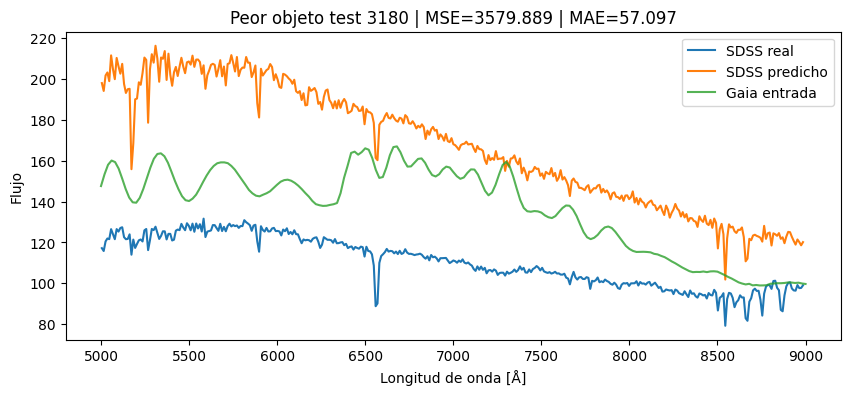

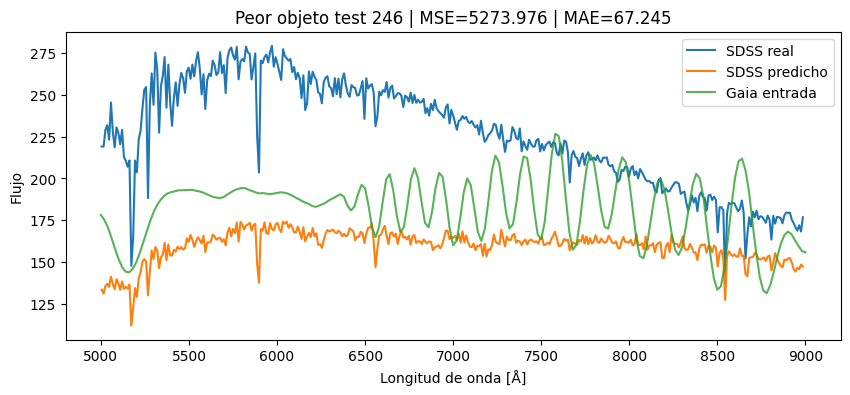

In [48]:
mae = np.mean(np.abs(y_test - y_pred))
mse = np.mean((y_test - y_pred) ** 2)
rmse = np.sqrt(mse)

mae_per_object = np.mean(np.abs(y_test - y_pred), axis=1)
mse_per_object = np.mean((y_test - y_pred) ** 2, axis=1)
rmse_per_object = np.sqrt(mse_per_object)

worst_idx = np.argsort(mse_per_object)[-10:]

for i in worst_idx:
    gaia_wavelength_ams = gaia_wavelength * 10
    gaia_in_sdss_units = X_test[i] / 1e-19

    plt.figure(figsize=(10, 4))
    plt.plot(sdss_wavelength_binned, y_test[i], label="SDSS real")
    plt.plot(sdss_wavelength_binned, y_pred[i], label="SDSS predicho")
    plt.plot(gaia_wavelength_ams, gaia_in_sdss_units, label="Gaia entrada", alpha=0.8)
    plt.xlabel("Longitud de onda [Å]")
    plt.ylabel("Flujo")
    plt.title(f"Peor objeto test {i} | MSE={mse_per_object[i]:.3f} | MAE={mae_per_object[i]:.3f}")
    plt.legend()
    plt.show()

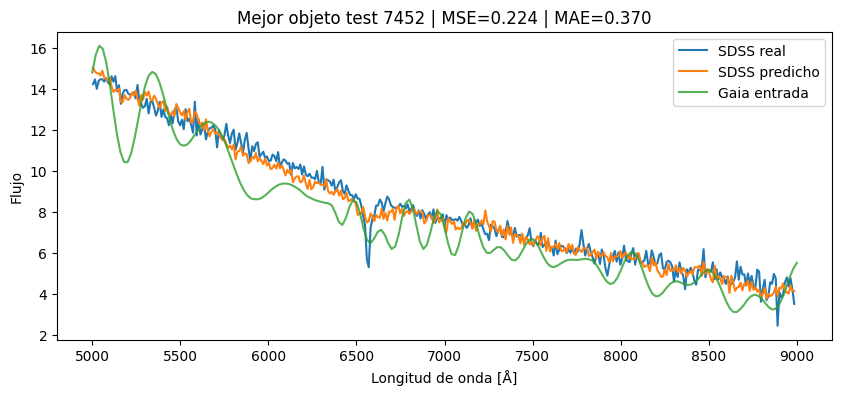

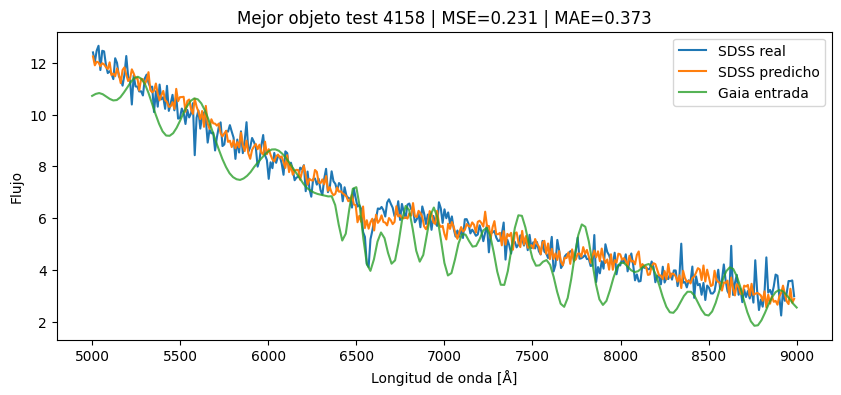

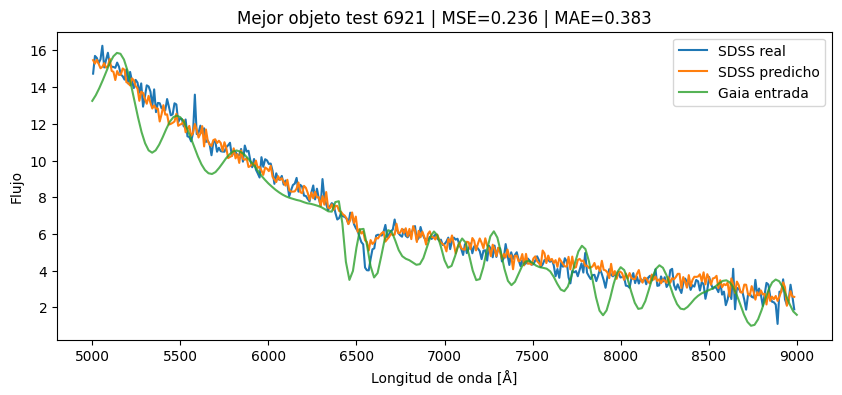

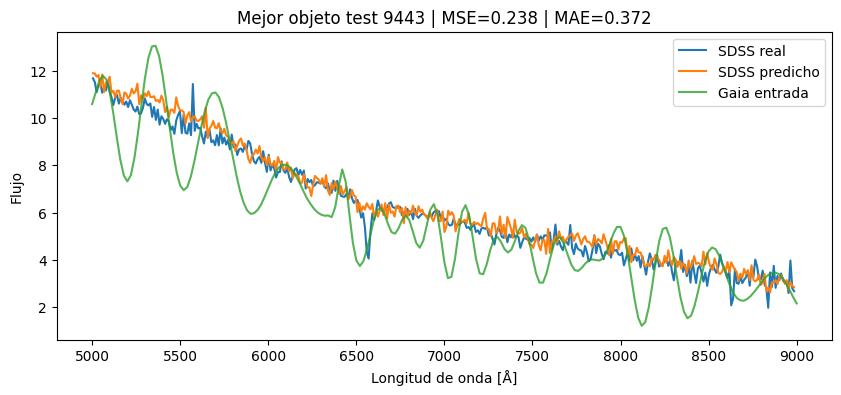

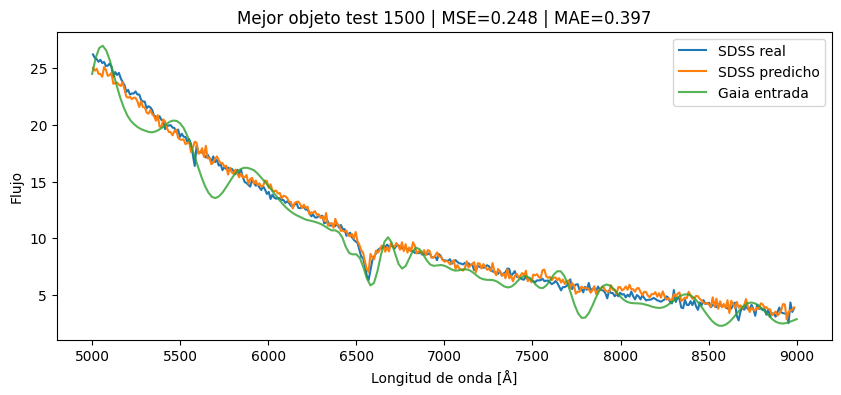

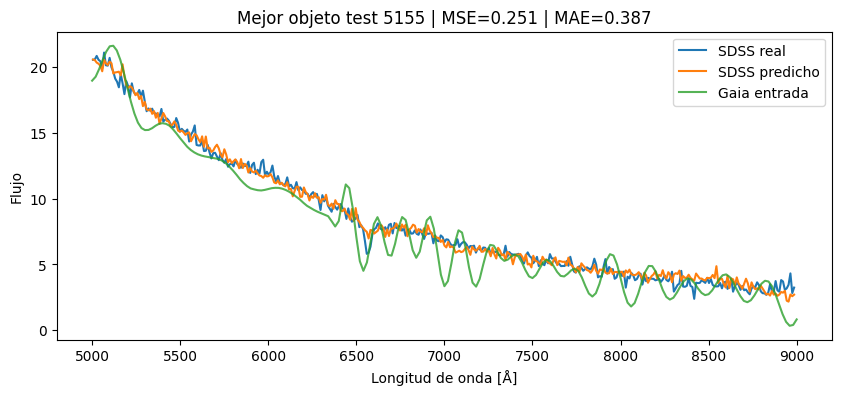

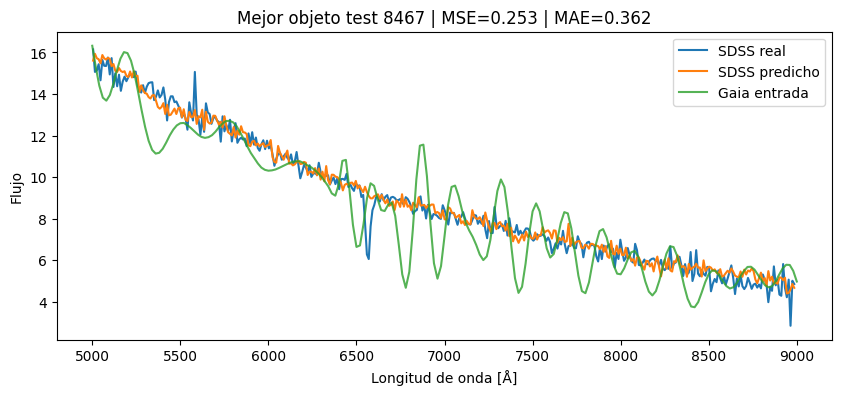

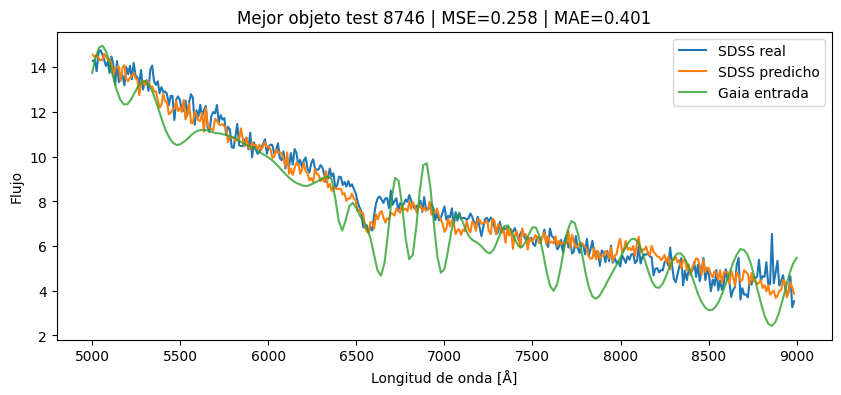

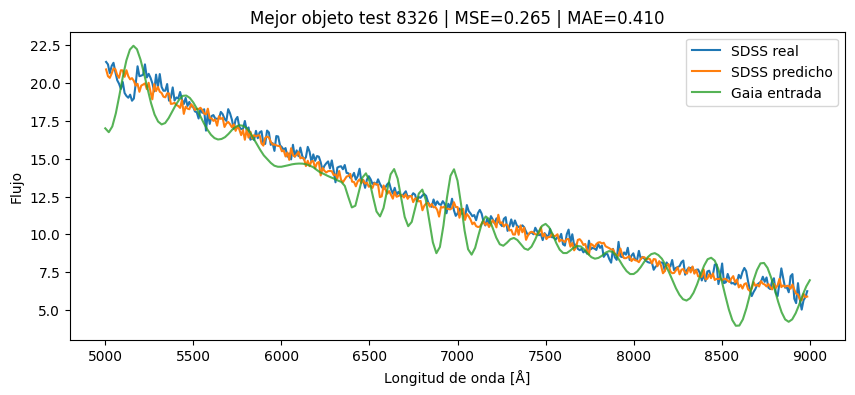

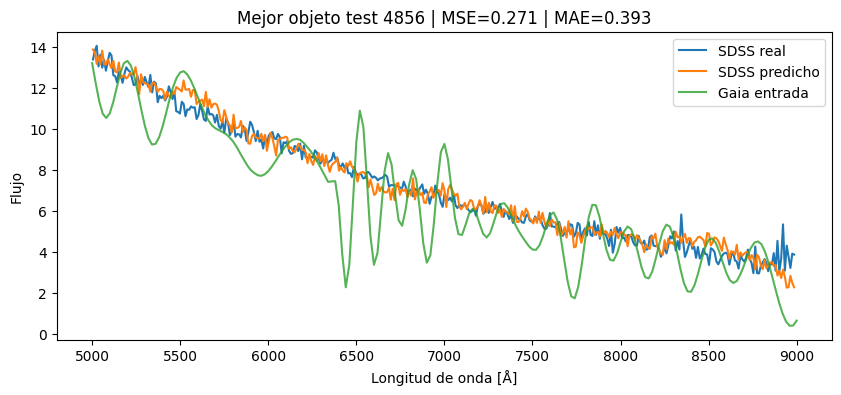

In [49]:
best_idx = np.argsort(mse_per_object)[:10]

for i in best_idx:
    gaia_wavelength_ams = gaia_wavelength * 10
    gaia_in_sdss_units = X_test[i] / 1e-19

    plt.figure(figsize=(10, 4))
    plt.plot(sdss_wavelength_binned, y_test[i], label="SDSS real")
    plt.plot(sdss_wavelength_binned, y_pred[i], label="SDSS predicho")
    plt.plot(gaia_wavelength_ams, gaia_in_sdss_units, label="Gaia entrada", alpha=0.8)
    plt.xlabel("Longitud de onda [Å]")
    plt.ylabel("Flujo")
    plt.title(f"Mejor objeto test {i} | MSE={mse_per_object[i]:.3f} | MAE={mae_per_object[i]:.3f}")
    plt.legend()
    plt.show()

Probamos un modelo diferente par capas convolucionales

In [ ]:
n_gaia = X_train_norm.shape[1]
n_sdss = y_train_norm.shape[1]

# Para Conv1D necesitamos forma (n_objetos, n_puntos, canales)
X_train_cnn = X_train_norm[..., None]
X_val_cnn = X_val_norm[..., None]
X_test_cnn = X_test_norm[..., None]

model_cnn = models.Sequential([
    layers.Input(shape=(n_gaia, 1)),

    layers.Conv1D(32, kernel_size=7, padding="same", activation="elu"),
    layers.Conv1D(64, kernel_size=7, padding="same", activation="elu"),
    layers.Conv1D(128, kernel_size=5, padding="same", activation="elu"),

    layers.Flatten(),

    layers.Dense(512),#, activation="elu"),#relu
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(1024, activation="elu"),
    
    layers.Dense(1024),
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(1024, activation="elu"),

    layers.Dense(n_sdss)
])

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

model_cnn.compile(
    optimizer=Adam(learning_rate=1e-4, clipnorm=1),
    loss= tf.keras.losses.Huber(delta=1.0),
    metrics=["mae", "mse"]
)

model_cnn.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 201, 32)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 201, 64)        │        14,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 201, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25728)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 512)            │    13,173,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_16 (LeakyReLU)      │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_17 (LeakyReLU)      │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 380)            │       389,500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,243,004 (61.96 MB)

 Trainable params: 16,243,004 (61.96 MB)

 Non-trainable params: 0 (0.00 B)

In [80]:
history = model_cnn.fit(
    X_train_cnn,
    y_train_norm,
    validation_data=(X_val_cnn, y_val_norm),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop,reduce_lr],
    verbose=1
)

Epoch 1/50


306/306 ━━━━━━━━━━━━━━━━━━━━ 42s 130ms/step - loss: 0.1011 - mae: 0.2689 - mse: 0.3410 - val_loss: 0.0325 - val_mae: 0.1076 - val_mse: 0.1305 - learning_rate: 1.0000e-04
Epoch 2/50
306/306 ━━━━━━━━━━━━━━━━━━━━ 41s 135ms/step - loss: 0.0304 - mae: 0.1092 - mse: 0.1111 - val_loss: 0.0407 - val_mae: 0.1500 - val_mse: 0.1478 - learning_rate: 1.0000e-04
Epoch 3/50
306/306 ━━━━━━━━━━━━━━━━━━━━ 36s 116ms/step - loss: 0.0253 - mae: 0.1028 - mse: 0.0877 - val_loss: 0.0323 - val_mae: 0.1039 - val_mse: 0.1368 - learning_rate: 1.0000e-04
Epoch 4/50
306/306 ━━━━━━━━━━━━━━━━━━━━ 38s 124ms/step - loss: 0.0277 - mae: 0.1005 - mse: 0.1062 - val_loss: 0.0298 - val_mae: 0.1041 - val_mse: 0.1175 - learning_rate: 1.0000e-04
Epoch 5/50
306/306 ━━━━━━━━━━━━━━━━━━━━ 36s 117ms/step - loss: 0.0293 - mae: 0.1027 - mse: 0.1102 - val_loss: 0.0283 - val_mae: 0.1007 - val_mse: 0.1152 - learning_rate: 1.0000e-04
Epoch 6/50
306/306 ━━━━━━━━━━━━━━━━━━━━ 38s 124ms/step - loss: 0.0254 - mae: 0.0990 - mse: 0.0859 - val_lo

In [81]:
test_loss, test_mae, test_mse = model_cnn.evaluate(
    X_test_cnn,
    y_test_norm,
    verbose=1
)

96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0200 - mae: 0.0879 - mse: 0.0624


In [82]:
y_pred_norm_cnn = model_cnn.predict(X_test_cnn)
y_pred_cnn = y_pred_norm * y_std + y_mean
y_test_recalculated_cnn = y_test_norm * y_std + y_mean

96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step


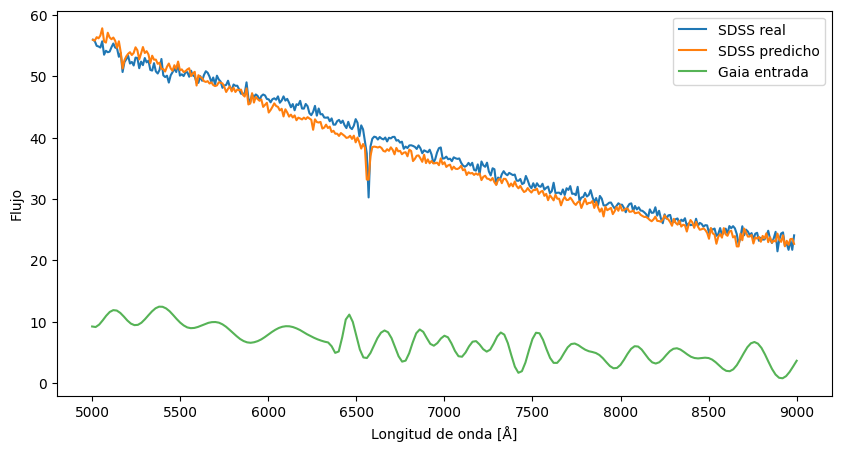

In [84]:
import matplotlib.pyplot as plt

i = 14

gaia_wavelength_ams = gaia_wavelength * 10
gaia_in_sdss_units_cnn = X_test[i] / 1e-19

plt.figure(figsize=(10, 5))
plt.plot(sdss_wavelength_binned, y_test[i], label="SDSS real")
plt.plot(sdss_wavelength_binned, y_pred_cnn[i], label="SDSS predicho")
plt.plot(gaia_wavelength_ams, gaia_in_sdss_units, label="Gaia entrada", alpha=0.8)
plt.xlabel("Longitud de onda [Å]")
plt.ylabel("Flujo")
plt.legend()
plt.show()